## Artificial intelligence-enabled electrocardiogram to detect digoxin exposure 
#### Inference Notebook 

In [1]:
from __future__ import annotations
import os         
import os
import json
import sys
import re
import copy
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import ast
%load_ext autoreload
%autoreload 2
import random
from pathlib import Path
import math
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score, average_precision_score
from ml4h.defines import PARTNERS_DATETIME_FORMAT, ECG_REST_AMP_LEADS
from ml4h.TensorMap import TensorMap, Interpretation
print(ECG_REST_AMP_LEADS)
import ecg2dig 
from ecg2dig.utils.datasets import ECGDrugDataset, ECGDataDescription
from ecg2dig.inference import inference
from ecg2dig.utils.datasets import is_valid_ecg, is_bound_ecg, safe_pearsonr
from ecg2dig.utils.helpers import load_model_from_weights, build_model_kwargs_from_log
from ecg2dig.utils.helpers import plot_roc_curves, subgroup_analysis
import importlib

2026-05-01 21:37:01.240224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 21:37:02.435004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777685822.781637   59982 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777685822.890841   59982 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777685823.511921   59982 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

{'I': 0, 'II': 1, 'III': 2, 'aVR': 3, 'aVL': 4, 'aVF': 5, 'V1': 6, 'V2': 7, 'V3': 8, 'V4': 9, 'V5': 10, 'V6': 11}


In [2]:
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                             brier_score_loss, roc_curve)

In [3]:
#importlib.reload(ecg2dig.utils.transforms)
from ecg2dig.utils.transforms import (ScaleECGTransform, 
                                     ToTensorTransform, 
                                     StandardizeByChannelECGTransform, 
                                     ClipECGByPercentileTransform,
                                     StandardizeTransform,
                                     StandardizeByChannelECGTransform)
from ecg2dig.ECG2DIG import ECG2DIG

In [4]:
REPO_ROOT = Path.cwd()
ROOT_DIR = '/data/cvrepo/' 
print(ROOT_DIR)
device = 'cpu'

/data/cvrepo/


In [5]:
def _load_data(filepath:str, 
                 verbose:bool = False,
                 dig_threshold:float = 0.,
                 drop_duplicates:bool = False,
                 use_multi_class:bool = False,
                 randomize_hr:bool = False,
                 ):

    try:
        df = pd.read_csv(filepath, sep='\t', 
                         encoding='iso-8859-1', 
                         low_memory=False)  
        
        # Restore dtypes
        df['ecg_datetime'] = pd.to_datetime(df['ecg_datetime'])
        df['measurement_datetime'] = pd.to_datetime(df['measurement_datetime'])
            
        print(df.head(1))

        # create binary OR 3-way variable
        if use_multi_class:
            df['high_digoxin'] = np.select([
                                (df['dig_level'] == 0),
                                (df['dig_level'] > 0) & (df['dig_level'] <= 2),
                                (df['dig_level'] > 2)],
                                [0, 1, 2],
                                default=np.nan
                                ).astype('int8') 
            # where Class 0: dig_level == 0, Class 1: 0 < dig_level ≤ 2, 
            # and Class 2: dig_level  > 2'
            print(f'Created 3-way variable: "high_digoxin"')
        else:   
            df["high_digoxin"] = df.dig_level > dig_threshold
            print(f'Created binary variable: "high_digoxin" with threshold: {dig_threshold}')

        print(df.shape)
        print(df.high_digoxin.value_counts())

        if drop_duplicates: 
            # Sort the dataframe by high_digoxin in descending order (2, 1, 0)
            # then by date descending as a tiebreaker
            # Then drop duplicates in the 'EMPI' column, 
            # keeping only the first occurrence 
            # (which will be the highest priority high_digoxin value)
            print(f'Dropping duplicates..(shape before): {df.shape}')
            print(df.high_digoxin.value_counts())
            df = df.sort_values(['high_digoxin', 'ecg_datetime'], 
                                ascending=[False, False]).drop_duplicates(subset=['EMPI'])
            print(f'After drop duplicates: {df.shape}')
            print(df.high_digoxin.value_counts())
            # Reset the index if needed
            df = df.reset_index(drop=True)        
        print(f'Dataset of shape {df.shape} loaded. Features: {list(df.columns)}')
        return df
    
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
    except pd.errors.ParserError:
        print(f"Error: Failed to parse CSV file at {filepath}. Check the file format.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    
    return None

def create_dataloader(
            ROOT_DIR: str, 
            val_path: str, 
            batch_size: int, 
            meta_columns: Optional[List[str]] = None, 
            use_multi_class = False,
            dig_threshold: float = 0.,
            workers = 0,
            verbose = True,
            drop_duplicates=False,
    ) -> DataLoader:
    
    """
    Creates val dataloader for inference
    Args:
        ROOT_DIR (str): Root dir e.g for ERISXDL:'/data/cvrepo/'
        batch_size (int): Batch size of the loader to create
        val_path (str): Path to the validation pandas dataset file (e.g. csv)
        meta_columns (list): Optional other features besides ecg, digoxin, 
        
        NOTE: the classification variable high_digoxin is added to the dataset
    """
    
    val_df = _load_data(os.path.join(
                        ROOT_DIR, val_path), 
                        dig_threshold = dig_threshold,
                        use_multi_class = use_multi_class,
                        drop_duplicates = drop_duplicates) 
    
    assert val_df is not None, "val_df is None: check data split/loading in get_dataloaders()"

    # ------
    # 1 - non-ECG Transforms
    # Calculate statistics 
    # --------
    
    feature_names = ['age_at_ecg_days', 'dig_level'] 
    print(f'Feature names ={feature_names}')
    print(f'meta columns ={meta_columns}')   

    print(f'Standardizing features: {feature_names}')
    
    # Calculate statistics 
    feature_means = {feat: val_df[feat].mean() for feat in feature_names}
    feature_stds  = {feat: val_df[feat].std()  for feat in feature_names}
    
    if verbose:
        print('Checking transformed values')
        for key, value in feature_means.items():
            if key == 'age_at_ecg_days':
                print(f"{key} (mean): {value/365:.3f}")
            else: 
                print(f"{key} (mean): {value:.3f}")

        for key, value in feature_stds.items():
            if key == 'age_at_ecg_days':
                print(f"{key} (std): {value/365:.3f}")
            else: 
                print(f"{key} (std): {value:.3f}")
    
    # Create the non-ECG transforms combination
    standardize_transform = transforms.Compose([
                    StandardizeTransform(feature_means, feature_stds),
                   ])
    # ------
    # 2 - ECG Transforms 
    # ------
    ecg_transform = transforms.Compose([
            ToTensorTransform(), # Tensor [T, C], still in raw values (e.g.3000)
            ScaleECGTransform(), # Tensor [T, C], now in millivolts
            #ClipECGByPercentileTransform(),
            StandardizeByChannelECGTransform(),
            #StandardizeTransform,
            #StandardizeByChannelECGTransform
            ])

    print(f'ECG Transforms: {ecg_transform}')
    
    # ml4h ECG Tensor and Transforms
    ecg_tmap = TensorMap(
        'ecg_5000_std',
        Interpretation.CONTINUOUS,
        shape=(5000, 12),
    )

    ecg_dd = ECGDataDescription(
            f'{ROOT_DIR}ecgs/',  # folder with MRN_path.h5 files
            name=ecg_tmap.input_name(), 
            ecg_len=5000,  # ECGs linearly interpolated to this length 
            transforms=ecg_transform  
            )
    
    labels = val_df["high_digoxin"].to_numpy(dtype=np.int64)
           
    val_dataset = ECGDrugDataset(
                        dataframe=val_df, 
                        ecg_dataset=ecg_dd,
                        meta_columns=meta_columns,
                        transform=standardize_transform,
                        ecg_transform=ecg_transform,
    )
    
    def safe_collate(batch):
        """Drop None samples from batch"""
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None  
        return torch.utils.data.dataloader.default_collate(batch)
    
    loader = DataLoader(
                    dataset=val_dataset, 
                    batch_size=batch_size, 
                    drop_last=False,
                    shuffle=False,  # We do not want shuffling here 
                    pin_memory=False,
                    num_workers=workers,
                    collate_fn=safe_collate
                    )
    return loader

### Loading datasets

Requirements:

**A pandas .tsv file contaning a dataframe with the following columns:**

- MRN_path
- ecg_datetime
- measurement_datetime <- only used to find the ecg_datetime within 24 h
- dig_level <- digoxin numeric level e.g. 0.2

```
ecg_dd = ECGDataDescription(
        f'{ROOT_DIR}ecgs/',  # folder with MRN_path.h5 files
        name=ecg_tmap.input_name(), 
        ecg_len=5000,  # ECGs linearly interpolated to this length 
        transforms=ecg_transform  
        )
MRN_path = ecg_bwh_hd5s/72389
```

The model was trained as a **3-class classifier (num_classes=3)**.<BR>
- use_multi_class: True
- num_classes: 3 (no dig / therapeutic / suprather).
- dig_threshold: 0 - ignored

In [6]:
use_multi_class = True

In [12]:
# ================
# TOY SET FOR for demo purposes
# measurement_datetime is nan for control group
# ================

val_path = Path(REPO_ROOT / 'val_digoxin_dummy.tsv')
val_df = pd.read_csv(val_path, sep='\t')
val_df['ecg_datetime'] = pd.to_datetime(val_df['ecg_datetime'], errors='coerce')
val_df['ecg_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')
val_df['measurement_datetime'] = pd.to_datetime(val_df['measurement_datetime'], errors='coerce')
val_df['measurement_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')
print(val_df.shape)
val_df.head()

(9, 6)


,MRN_path,ecg_datetime,measurement_datetime,dig_level,age_at_ecg_days,female
0,ecg_mgh_hd5s/5121213,2012-02-13 16:12:00,NaT,0.0,16068,0
1,ecg_mgh_hd5s/3413260,2016-11-06 10:52:11,NaT,0.0,18717,1
2,ecg_bwh_hd5s/2781425,2004-06-11 16:19:33,2004-06-11 15:15:00,2.1,24952,0
3,ecg_mgh_hd5s/4843934,2017-08-10 13:46:11,2017-08-10 16:24:00,2.3,31065,1
4,ecg_mgh_hd5s/1422157,1986-08-26 18:22:00,NaT,0.0,20045,1


In [13]:
# check time difference - should return empty
mask = (val_df['ecg_datetime'] - val_df['measurement_datetime']).abs() > pd.Timedelta(hours=24)
df_exceeds = val_df[mask]
print(f"{len(df_exceeds)} rows exceed 24 hours")
df_exceeds.head()

0 rows exceed 24 hours


,MRN_path,ecg_datetime,measurement_datetime,dig_level,age_at_ecg_days,female


**'ecg_datetime' should be within 24 hours of the 'meaasurement_datetime'**

In [15]:
meta_columns = []
batch_size = 256
val_loader = create_dataloader(
                    ROOT_DIR = ROOT_DIR, 
                    batch_size = batch_size, 
                    val_path = val_path, 
                    meta_columns = meta_columns,
                    use_multi_class = True,
                    workers = 0,
                    verbose = True,
                    drop_duplicates=False)
print(len(val_loader))
print(val_loader.dataset.df.shape)
val_df = val_loader.dataset.df
val_df.shape
val_df.head(2)

               MRN_path        ecg_datetime measurement_datetime  dig_level  \
0  ecg_mgh_hd5s/5121213 2012-02-13 16:12:00                  NaT        0.0   

   age_at_ecg_days  female  
0            16068       0  
Created 3-way variable: "high_digoxin"
(9, 7)
high_digoxin
0    5
2    2
1    2
Name: count, dtype: int64
Dataset of shape (9, 7) loaded. Features: ['MRN_path', 'ecg_datetime', 'measurement_datetime', 'dig_level', 'age_at_ecg_days', 'female', 'high_digoxin']
Feature names =['age_at_ecg_days', 'dig_level']
meta columns =[]
Standardizing features: ['age_at_ecg_days', 'dig_level']
Checking transformed values
age_at_ecg_days (mean): 61.235
dig_level (mean): 0.633
age_at_ecg_days (std): 13.065
dig_level (std): 0.934
ECG Transforms: Compose(
)
1
(9, 7)


,MRN_path,ecg_datetime,measurement_datetime,dig_level,age_at_ecg_days,female,high_digoxin
0,ecg_mgh_hd5s/5121213,2012-02-13 16:12:00,NaT,0.0,16068,0,0
1,ecg_mgh_hd5s/3413260,2016-11-06 10:52:11,NaT,0.0,18717,1,0


### Loading model
The ECG2DIG  model returns six outputs (two of which are discarding). The architecture is num_classes=3.
```
cls_logits, attn_weights, hr_out, dig_out, _, _ = model(xb)
```
- cls_logits — shape [B, num_classes], here [B, 3]. Raw (pre-softmax) scores for the digoxin classification head. Index 0 = no digoxin, 1 = therapeutic (0–2 ng/mL), 2 = supra (>2 ng/mL). 
- attn_weights — shape roughly [B, 12] or [B, 12, 1]. Per-lead attention weights for SHAP interpretability
- hr_out — shape [B, 1]. Regression prediction for heart rate (an auxiliary head). Should be un-standardize before comparing to real HR values.
- dig_out — shape [B, 1]. Regression prediction for the continuous digoxin level (separate from the 3-class head).  Standardized during training.
-	_, _ ignored. 


In [16]:
# Loading the training params
training_log = Path(REPO_ROOT / 'models/training.log') 
kwargs = build_model_kwargs_from_log(training_log)

model_kwargs = {'name': 'ECG2DIG',
                'num_classes': 3,
                'feat_dim': 512
               }
print(kwargs)
print(model_kwargs)

{'name': 'ECG2DIG', 'num_classes': 3, 'dig_threshold': 0}
{'name': 'ECG2DIG', 'num_classes': 3, 'feat_dim': 512}


In [17]:
model_weights = Path(REPO_ROOT / 'models/model_best_state_dict.pt')
model = load_model_from_weights(
    model_path=model_weights,
    model_kwargs=model_kwargs,
    device=device,
    strict=True,   # False only if we expect small key mismatches
)

In [18]:
%%time
use_multiclass = True

full_df = inference(model=model, 
              loader=val_loader, 
              device=device,
              use_multi_class=True, #use_multiclass,
              output_dir=''  # set if needed
             )

Inference started!
--------
INFERENCE
-----------

[DEBUG] use_multi_class = True
[DEBUG] label_col = 'dig_class_true'
Inside forward pass


Inference: 100%|██████████| 1/1 [00:05<00:00,  5.52s/it]

full_df created: (9, 14)
Digoxin ROC AUC (macro): 0.8095
Digoxin Macro F1:        0.4167
Per-class AUC (OVR):     class0: 1.0000 | class1: 0.7143 | class2: 0.7143
Per-class F1:            class0: 0.7500 | class1: 0.5000 | class2: 0.0000
Per-class AP:            class0: 1.0000 | class1: 0.4167 | class2: 0.4500
DIG Pearson r:           0.7581
Notes:
  - class 2: never predicted (2 true samples) → F1 = 0
CPU times: user 20.2 s, sys: 2.63 s, total: 22.8 s
Wall time: 5.6 s


In [19]:
full_df.shape

(9, 14)

age_at_ecg_days: min=16068, max=31065, median=20446 (median ≈ 56.0 years)


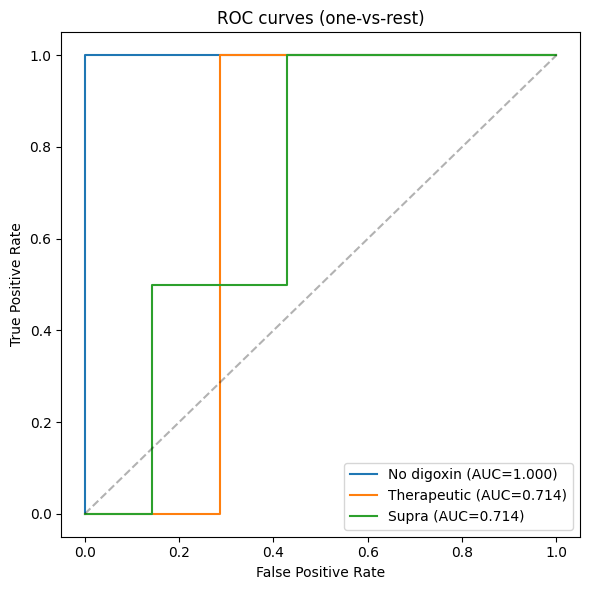

Derived threshold for specificity >= 0.95: inf

OVERALL (class 2 vs. rest)

Overall @ threshold=inf:
  Prevalence:  0.222   (n=2/9)
  Sensitivity: 0.000   (TP=0, FN=2)
  Specificity: 1.000   (TN=7, FP=0)
  PPV:           nan
  NPV:         0.778
  Notes:
    - PPV is undefined — model predicts no positives at threshold inf (TP+FP = 0); no cases to check precision on

BY SEX

--- Female (n=5) ---
  AUC: 0.750   AP: 0.500

Female @ threshold=inf:
  Prevalence:  0.200   (n=1/5)
  Sensitivity: 0.000   (TP=0, FN=1)
  Specificity: 1.000   (TN=4, FP=0)
  PPV:           nan
  NPV:         0.800
  Notes:
    - PPV is undefined — model predicts no positives at threshold inf (TP+FP = 0); no cases to check precision on

--- Male (n=4) ---
  AUC: 0.667   AP: 0.500

Male @ threshold=inf:
  Prevalence:  0.250   (n=1/4)
  Sensitivity: 0.000   (TP=0, FN=1)
  Specificity: 1.000   (TN=3, FP=0)
  PPV:           nan
  NPV:         0.750
  Notes:
    - PPV is undefined — model predicts no positives at thres

In [20]:
# ROC curves
print(f"age_at_ecg_days: min={val_df['age_at_ecg_days'].min():.0f}, "
      f"max={val_df['age_at_ecg_days'].max():.0f}, "
      f"median={val_df['age_at_ecg_days'].median():.0f} "
      f"(median ≈ {val_df['age_at_ecg_days'].median()/365.25:.1f} years)")
plot_roc_curves(full_df)

# Subgroup analysis, focusing on class 2 (supra) as the clinically critical call
used_threshold = subgroup_analysis(
    full_df, target_class=2, target_spec=0.95
)

In [21]:
def evaluate_ovr_auc_pr_ci_df(
    df: pd.DataFrame,
    logits_col: str = "cls_logits",
    label_col: str  = "cls_true",
    calibrate_fn=None,                
    n_boot: int = 1000,
    seed: int = 42,
    patient_id_col: str | None = "patient_id",  # clustered if present; IID otherwise
):
    """
    Returns threshold-free OvR metrics with 95% CIs:
      {
        'n': N,
        'per_class': {
          'class0': {'prevalence': ..., 'AUC': ..., 
          'AUC_CI': (..,..), 'PR_AUC': ..., 'PR_AUC_CI': (..,..), 
          'n_pos': .., 'n_neg': ..},
          'class1': {...},
          'class2': {...}
        },
        'macro_ovr_auc': float, 'macro_ovr_auc_CI': (..,..),
        'macro_ovr_ap':  float, 'macro_ovr_ap_CI':  (..,..)
      }
    """
    
    def _softmax(z):
        z = z - z.max(axis=1, keepdims=True)
        ez = np.exp(z)
        return ez / ez.sum(axis=1, keepdims=True)
    
    def _to_logits(col, n_classes=3):
        ''' Helper to clean up logits. 
        Returns a numpy array of floats
        '''
        def to_arr(v):
            if isinstance(v, str): v = ast.literal_eval(v)
            return np.asarray(v, float).reshape(-1)
        A = np.stack([to_arr(v) for v in col], axis=0)
        if A.shape[1] != n_classes:
            raise ValueError(f"Expected {n_classes} logits, got {A.shape[1]}")
        return A
    
    def _auc_safe(yb, s):
        ''' Computes the ROC AUC score between true labels `yb` and 
        predicted scores `s`, safely, that is, returns `np.nan` 
        instead of raising an error when only one class is present in 
        the labels. This prevents crashes during bootstrap resampling 
        or other scenarios where you might randomly get a 
        homogeneous sample with all 0s or all 1s.
        '''
        return float(roc_auc_score(yb, s)) if len(np.unique(yb)) > 1 else np.nan

    def _ap_safe(yb, s):
        return float(average_precision_score(yb, s)) if len(np.unique(yb)) > 1 else np.nan
    
    def _iid_boot_indices(n, B, rng):
        ''' Generates bootstrap sample indices for resampling.
        '''
        return [rng.integers(0, n, n) for _ in range(B)]
    
    def _ci(vals, alpha=0.05):
        ''' Computes a confidence interval from an array of values 
        using the percentile method, returning the lower and upper 
        bounds at the specified `alpha` level (default 95% CI with alpha=0.05). 
        It returns `(np.nan, np.nan)` if the input is empty or contains only 
        NaN values, otherwise it calculates and returns the `alpha/2` 
        and `1-alpha/2` percentiles (e.g., 2.5th and 97.5th percentiles for a 95% CI).
        '''
        v = np.asarray(vals, float)
        if v.size == 0 or np.all(np.isnan(v)): return (np.nan, np.nan)
        lo, hi = np.nanpercentile(v, [100*alpha/2, 100*(1-alpha/2)])
        return (float(lo), float(hi))


    rng = np.random.default_rng(seed)
    # Parse logits/labels
    logits = _to_logits(df[logits_col], n_classes=3)
    print(f'Logits are shape: {logits.shape}')
    y = pd.to_numeric(df[label_col], errors="coerce").to_numpy()
    m = ~np.isnan(y)
    logits, y = logits[m], y[m].astype(int)
    N = len(y)
    # We use axis=1 in softmax because our logits are shaped (n_samples, n_classes) so
    # we want to apply softmax across the classes dimension for each sample, 
    # so each row (sample) has probabilities that sum to 1.
    probs = calibrate_fn(logits) if calibrate_fn is not None else _softmax(logits)
    # Bootstrap sets (clustered if patient_id available)
    if n_boot and N > 1:
        if patient_id_col and (patient_id_col in df.columns):
            boot_sets = cluster_boot_indices(df.loc[m, patient_id_col].to_numpy(), n_boot, rng)
        else:
            boot_sets = _iid_boot_indices(N, n_boot, rng)
    else:
        boot_sets = []
    per_class = {}
    auc_list, ap_list = [], []
    macro_auc_bs, macro_ap_bs = [], []
    for c in (0, 1, 2):
        yb = (y == c).astype(int)
        s  = probs[:, c]
        prev = float(yb.mean()); n_pos = int(yb.sum()); n_neg = int((1 - yb).sum())
        auc = _auc_safe(yb, s)
        ap  = _ap_safe(yb, s)
        auc_list.append(auc); ap_list.append(ap)
        auc_bs, ap_bs = [], []
        for idx in boot_sets:
            yb_b, s_b = yb[idx], s[idx]
            auc_bs.append(_auc_safe(yb_b, s_b))
            ap_bs.append(_ap_safe(yb_b, s_b))
        
        # Round CI tuples
        auc_ci = _ci(auc_bs) if boot_sets else (np.nan, np.nan)
        auc_ci = (round(auc_ci[0], 2), round(auc_ci[1], 2))
        
        ap_ci = _ci(ap_bs) if boot_sets else (np.nan, np.nan)
        ap_ci = (round(ap_ci[0], 2), round(ap_ci[1], 2))
        
        per_class[f"class{c}"] = {
            "prevalence": round(prev, 2), "n_pos": n_pos, "n_neg": n_neg,
            "AUC": round(auc, 2), "AUC_CI": auc_ci,
            "PR_AUC": round(ap, 2), "PR_AUC_CI": ap_ci,
        }
    # Macro OvR (mean of per-class values), with bootstrap CIs
    macro_ovr_auc = float(np.nanmean(auc_list)) if len(auc_list) else np.nan
    macro_ovr_ap  = float(np.nanmean(ap_list))  if len(ap_list)  else np.nan
    if boot_sets:
        for idx in boot_sets:
            aucs_b, aps_b = [], []
            for c in (0, 1, 2):
                yb_b = (y[idx] == c).astype(int); s_b = probs[idx, c]
                aucs_b.append(_auc_safe(yb_b, s_b))
                aps_b.append(_ap_safe(yb_b, s_b))
            macro_auc_bs.append(np.nanmean(aucs_b))
            macro_ap_bs.append(np.nanmean(aps_b))
        macro_auc_CI = _ci(macro_auc_bs)
        macro_ap_CI  = _ci(macro_ap_bs)
        # Round macro CIs
        macro_auc_CI = (round(macro_auc_CI[0], 2), round(macro_auc_CI[1], 2))
        macro_ap_CI = (round(macro_ap_CI[0], 2), round(macro_ap_CI[1], 2))
    else:
        macro_auc_CI = (np.nan, np.nan)
        macro_ap_CI  = (np.nan, np.nan)
    
    return {
        "n": int(N),
        "per_class": per_class,
        "macro_ovr_auc": macro_ovr_auc, "macro_ovr_auc_CI": macro_auc_CI,
        "macro_ovr_ap":  macro_ovr_ap,  "macro_ovr_ap_CI":  macro_ap_CI,
    }

In [22]:
df_test = full_df.copy()
df_test.rename(columns={'high_digoxin': 'cls_true'}, inplace=True)
df_test["cls_logits"] = df_test["cls_logits"].apply(lambda s: np.asarray(ast.literal_eval(s), float) if isinstance(s, str) else np.asarray(s, float))

In [23]:
%%time 
res_ovr = evaluate_ovr_auc_pr_ci_df( 
    df_test,
    calibrate_fn=None,          # or calibrate
    n_boot=1000,
    seed=42,
    patient_id_col="patient_id" # clustered bootstrap if present
)
from pprint import pprint
pprint(res_ovr)
res_ovr["per_class"]["class2"]["AUC"], res_ovr["per_class"]["class2"]["AUC_CI"]

Logits are shape: (9, 3)


/tmp/ipykernel_59982/2611564664.py:133: RuntimeWarning: Mean of empty slice
  macro_auc_bs.append(np.nanmean(aucs_b))
/tmp/ipykernel_59982/2611564664.py:134: RuntimeWarning: Mean of empty slice
  macro_ap_bs.append(np.nanmean(aps_b))
/tmp/ipykernel_59982/2611564664.py:133: RuntimeWarning: Mean of empty slice
  macro_auc_bs.append(np.nanmean(aucs_b))
/tmp/ipykernel_59982/2611564664.py:134: RuntimeWarning: Mean of empty slice
  macro_ap_bs.append(np.nanmean(aps_b))
/tmp/ipykernel_59982/2611564664.py:133: RuntimeWarning: Mean of empty slice
  macro_auc_bs.append(np.nanmean(aucs_b))
/tmp/ipykernel_59982/2611564664.py:134: RuntimeWarning: Mean of empty slice
  macro_ap_bs.append(np.nanmean(aps_b))
/tmp/ipykernel_59982/2611564664.py:133: RuntimeWarning: Mean of empty slice
  macro_auc_bs.append(np.nanmean(aucs_b))
/tmp/ipykernel_59982/2611564664.py:134: RuntimeWarning: Mean of empty slice
  macro_ap_bs.append(np.nanmean(aps_b))
/tmp/ipykernel_59982/2611564664.py:133: RuntimeWarning: Mean of 

{'macro_ovr_ap': 0.6222222222222221,
 'macro_ovr_ap_CI': (0.57, 1.0),
 'macro_ovr_auc': 0.8095238095238096,
 'macro_ovr_auc_CI': (0.62, 1.0),
 'n': 9,
 'per_class': {'class0': {'AUC': 1.0,
                          'AUC_CI': (1.0, 1.0),
                          'PR_AUC': 1.0,
                          'PR_AUC_CI': (1.0, 1.0),
                          'n_neg': 4,
                          'n_pos': 5,
                          'prevalence': 0.56},
               'class1': {'AUC': 0.71,
                          'AUC_CI': (0.33, 1.0),
                          'PR_AUC': 0.42,
                          'PR_AUC_CI': (0.2, 1.0),
                          'n_neg': 7,
                          'n_pos': 2,
                          'prevalence': 0.22},
               'class2': {'AUC': 0.71,
                          'AUC_CI': (0.33, 1.0),
                          'PR_AUC': 0.45,
                          'PR_AUC_CI': (0.17, 1.0),
                          'n_neg': 7,
                        

(0.71, (0.33, 1.0))

In [24]:
from ecg2dig.metrics import (plot_decision_curve_analysis_df,
                             plot_multiclass_roc_df,
                             plot_multiclass_pr_df,
                             evaluate_calibration_df,
                             plot_ovo_roc_df,
                             plot_ovo_pr_df
                            )

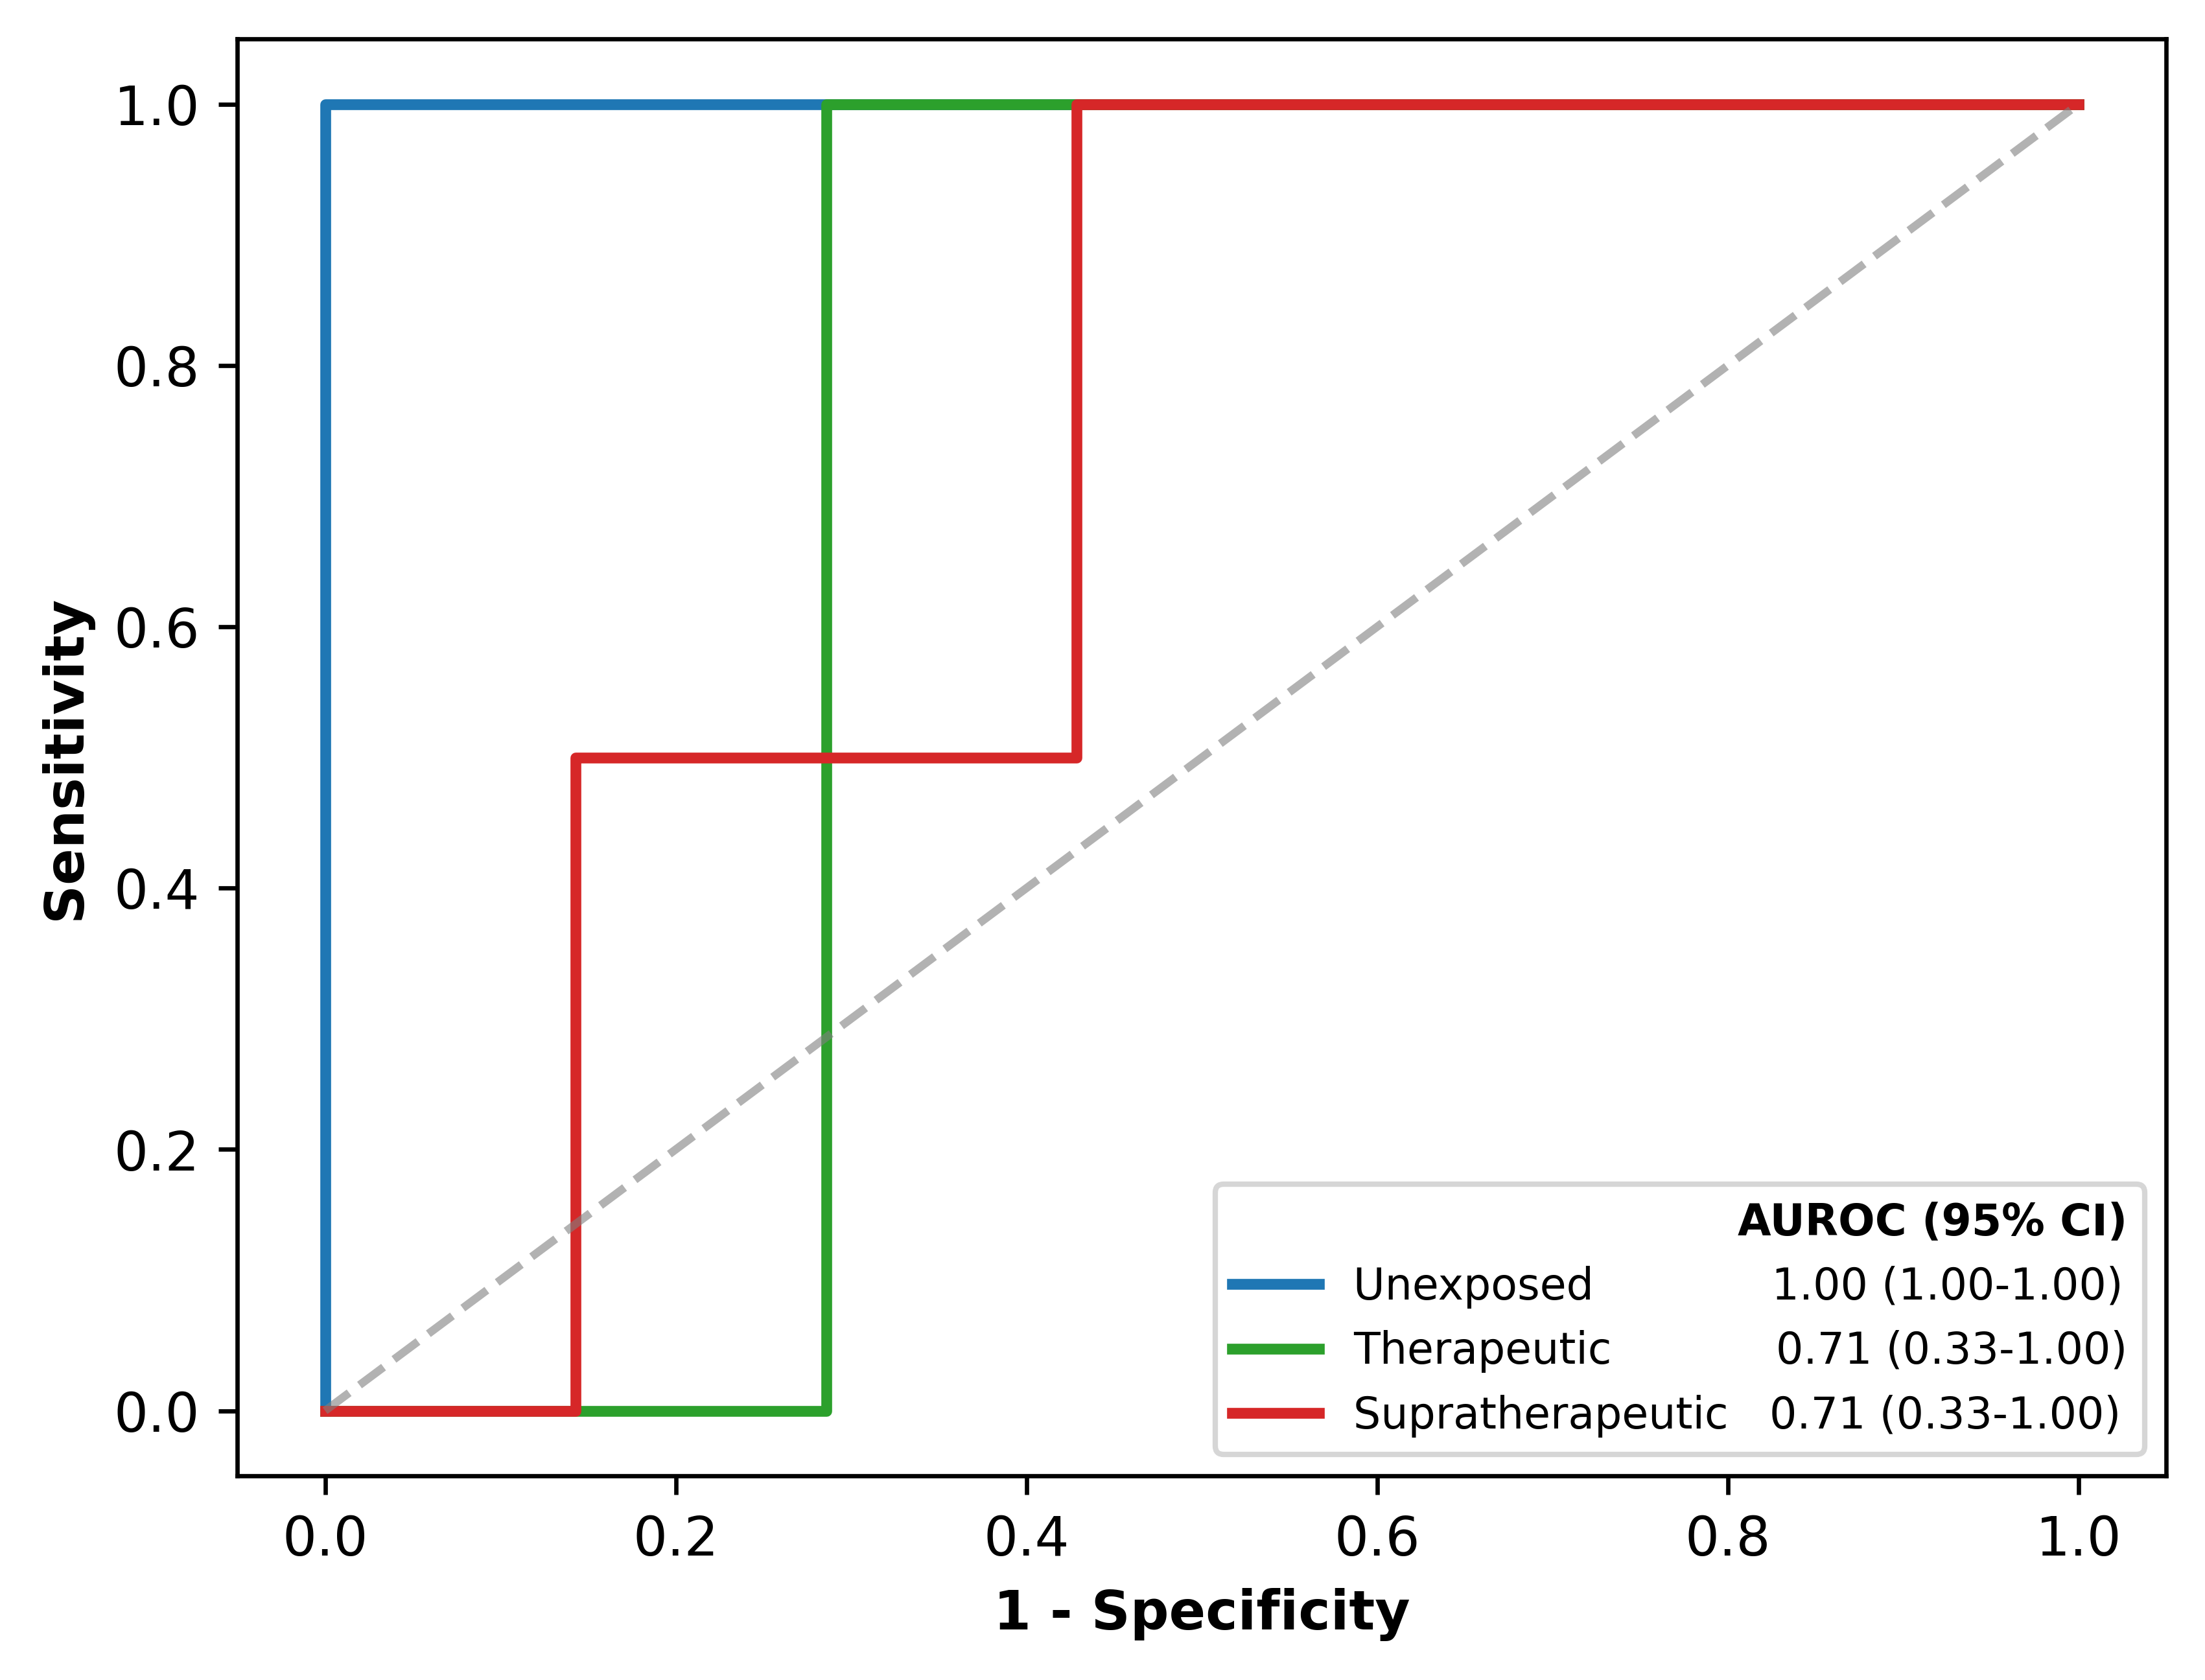

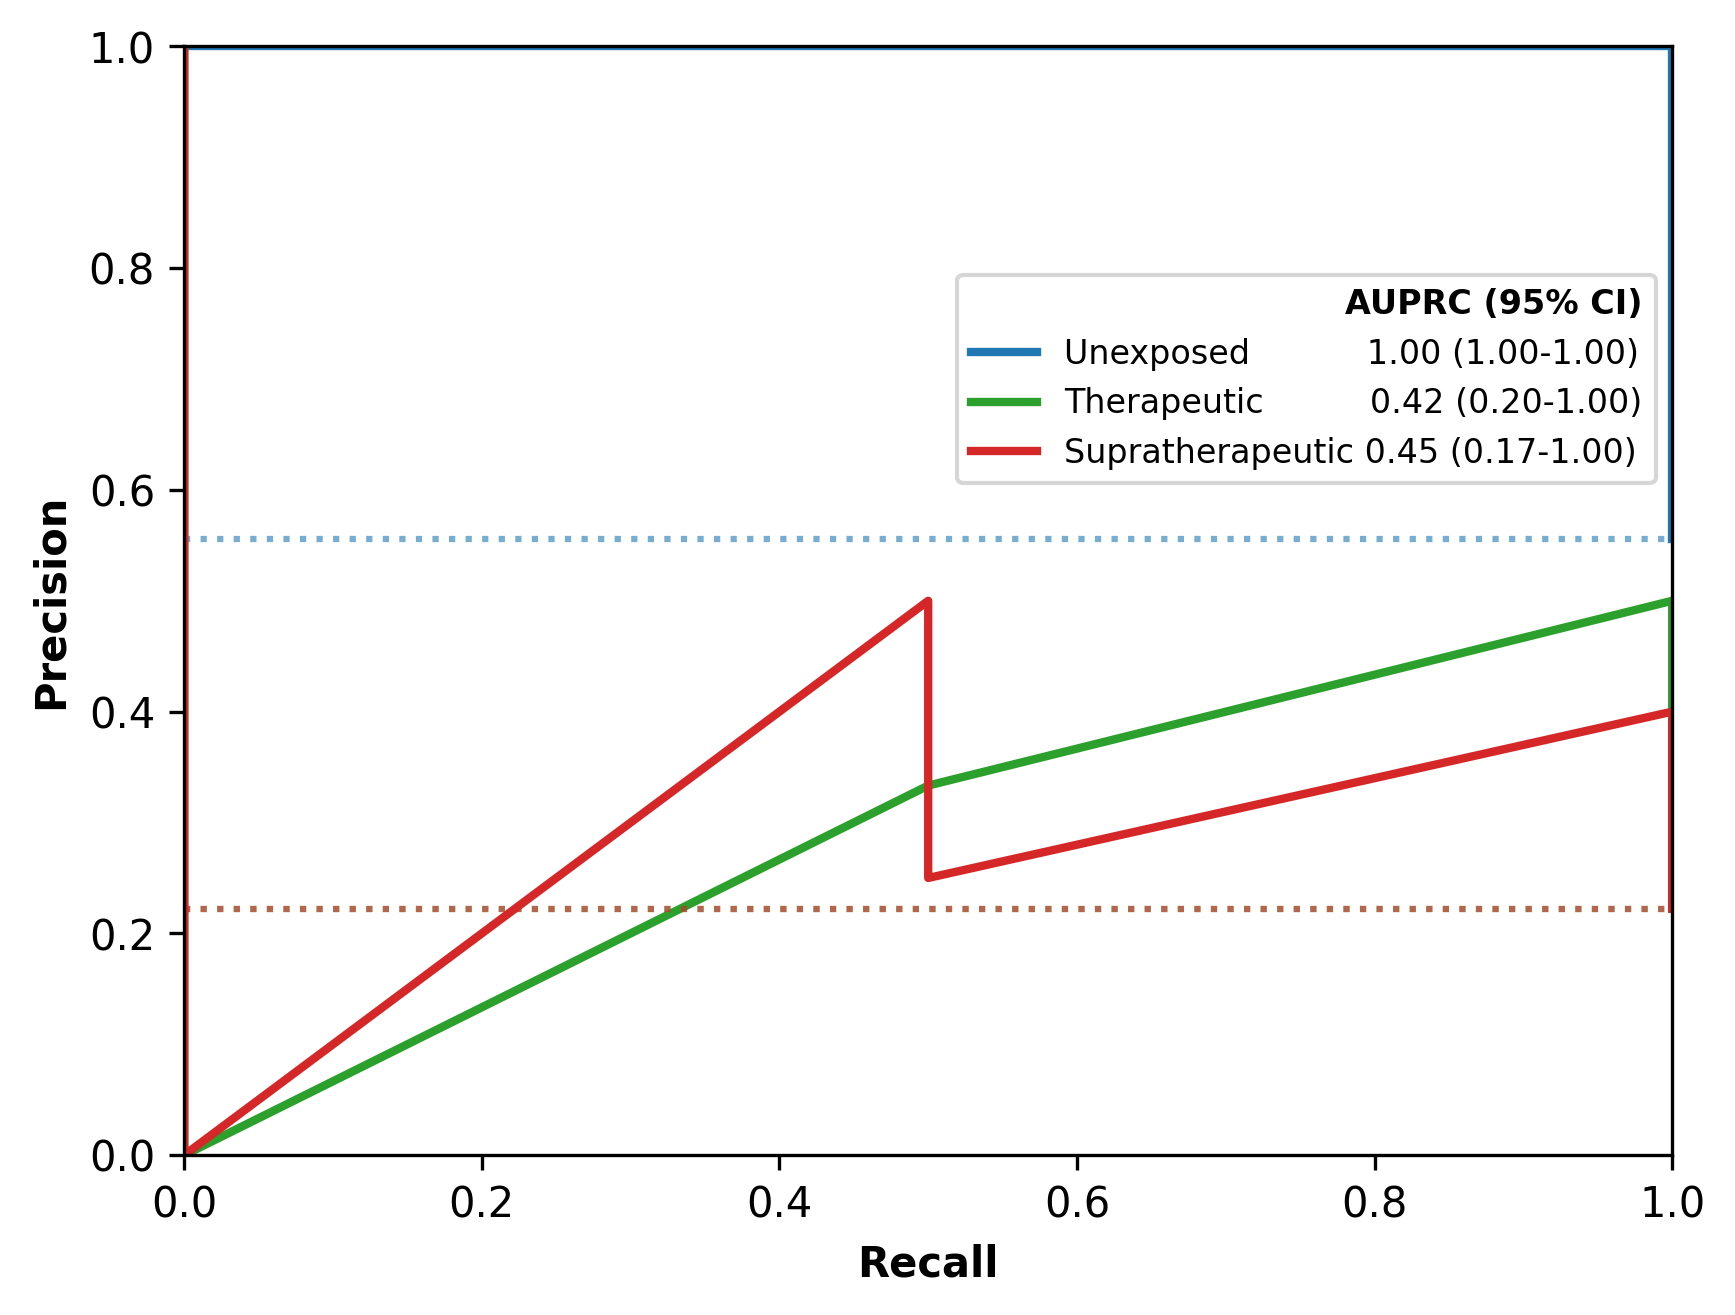

In [27]:
# Plots
class_names = ("Unexposed          ",
               "Therapeutic         ",
               "Supratherapeutic")
plot_multiclass_roc_df(df_test, 
                       class_names=class_names, 
                       save_path='ovr_auc_plot_Oct17',
                       legend_title='AUROC (95% CI)', 
                       res=res_ovr)
plot_multiclass_pr_df(df_test, 
                      class_names=class_names, 
                      save_path='ovr_pr_plot_Oct17',
                      legend_title='AUPRC (95% CI)', 
                      res=res_ovr)